In [11]:
import os
import sys
import pandas as pd
import numpy as np
import glob
import time
#import gget
import scipy
from scipy.sparse import csr_matrix
import anndata as an
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import random
from importlib import reload
import warnings
import ot
from scipy.spatial.distance import pdist, squareform
from matplotlib.colors import ListedColormap
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MinMaxScaler
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from kneed import KneeLocator  # pip install kneed

"""WARNING: no warnings"""
warnings.filterwarnings("ignore")

source_path = os.path.abspath("../utilities/")
sys.path.append(source_path)
import matrix as matrix
source_path = os.path.abspath("../utilities/calculations/")
sys.path.append(source_path)
import centrality as central

In [20]:
resolution = 1000000
chrom      = "chr3"
dpath      = "/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/by_chromosome/"

file_list       = sorted(glob.glob(f"{dpath}*_{resolution}_{chrom}*"))
population_path = file_list[0]
singlecell_path = file_list[1]
print(f"{population_path=}\n{singlecell_path=}\n")

t0 = time.time(); adata = sc.read_h5ad(population_path)
print(f"Population loaded in {time.time()-t0:.1f}s"); sc.logging.print_memory_usage()

t0 = time.time(); bdata = sc.read_h5ad(singlecell_path)
print(f"Single-cell loaded in {time.time()-t0:.1f}s"); sc.logging.print_memory_usage()

CN     = pd.read_csv("core_nodes.csv")
CE     = pd.read_csv("core_edges.csv")
H_core = sp.load_npz("H_core.npz")
print(f"\nCN: {len(CN)} core nodes  |  CE: {len(CE)} core edges  |  H_core: {H_core.shape}")

population_path='/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/by_chromosome/population_mESC_1000000_chr3.h5ad'
singlecell_path='/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/by_chromosome/singlecell_mESC_1000000_chr3.h5ad'

Population loaded in 3.3s
Memory usage: current 0.88 GB, difference -0.77 GB
Single-cell loaded in 13.3s
Memory usage: current 1.53 GB, difference +0.65 GB

CN: 467 core nodes  |  CE: 62447 core edges  |  H_core: (467, 62447)


In [21]:
def find_outliers_iqr(col):
    Q1, Q3 = col.quantile(0.15), col.quantile(0.85)
    IQR = Q3 - Q1
    return (col < Q1 - 1.5*IQR) | (col > Q3 + 1.5*IQR)

adata.obs['degree_outlier'] = find_outliers_iqr(adata.obs['chrom_degree'])
outliers = adata.obs[adata.obs['degree_outlier']].index.to_list()
print(f"Outlier loci: {len(outliers)}")

matrix.expand_and_normalize_anndata(adata, oe_kr=False)
matrix.expand_and_normalize_anndata(bdata, oe_kr=False)

Outlier loci: 1
Expanding input matrix...
Applying KR normalization...
Applying OE normalization...
Normalization complete.
Expanding input matrix...
Applying KR normalization...
Applying OE normalization...
Normalization complete.


In [22]:
N_CELLS = 10
cell_ids = list(bdata.var['basename'].unique())[:N_CELLS]

incidence_matrices = {}
for i, cell_id in enumerate(cell_ids):
    sc_data = bdata[:, bdata.var['basename'] == cell_id].copy()
    H_o = sc_data.to_df()
    H_o = H_o.T.drop_duplicates().T
    H_o.columns = [f"{cell_id}_{x}" for x in H_o.columns]
    incidence_matrices[cell_id] = H_o
    print(f"  {i+1}/{N_CELLS}  {cell_id}")

  1/10  o4b67
  2/10  o1b33
  3/10  o2b44
  4/10  o3b09
  5/10  o3b36
  6/10  o3b12
  7/10  o3b96
  8/10  o2b46
  9/10  o3b82
  10/10  o1b82


In [23]:
# Get locus index from first cell's clique-expanded matrix
_A0 = matrix.clique_expand_incidence(incidence_matrices[cell_ids[0]], zero_diag=False)
_A0 = _A0.sort_index(axis=0).sort_index(axis=1)
_A0 = _A0.drop(
    [o for o in outliers if o in _A0.index], axis=0
).drop(
    [o for o in outliers if o in _A0.columns], axis=1
)
locus_index = _A0.index

cn_bins        = set(CN["bin_name"].values)
core_mask      = np.array([b in cn_bins for b in locus_index])
core_positions = np.where(core_mask)[0]
print(f"Core nodes on {chrom}: {core_mask.sum()} / {len(locus_index)}")

Core nodes on chr3: 48 / 156


In [24]:
CMAP = "Reds"

def get_clique_matrix(cell_id):
    A = matrix.clique_expand_incidence(incidence_matrices[cell_id], zero_diag=False)
    A = A.sort_index(axis=0).sort_index(axis=1)
    A = A.drop([o for o in outliers if o in A.index], axis=0)\
         .drop([o for o in outliers if o in A.columns], axis=1)
    return np.log1p(A.values)

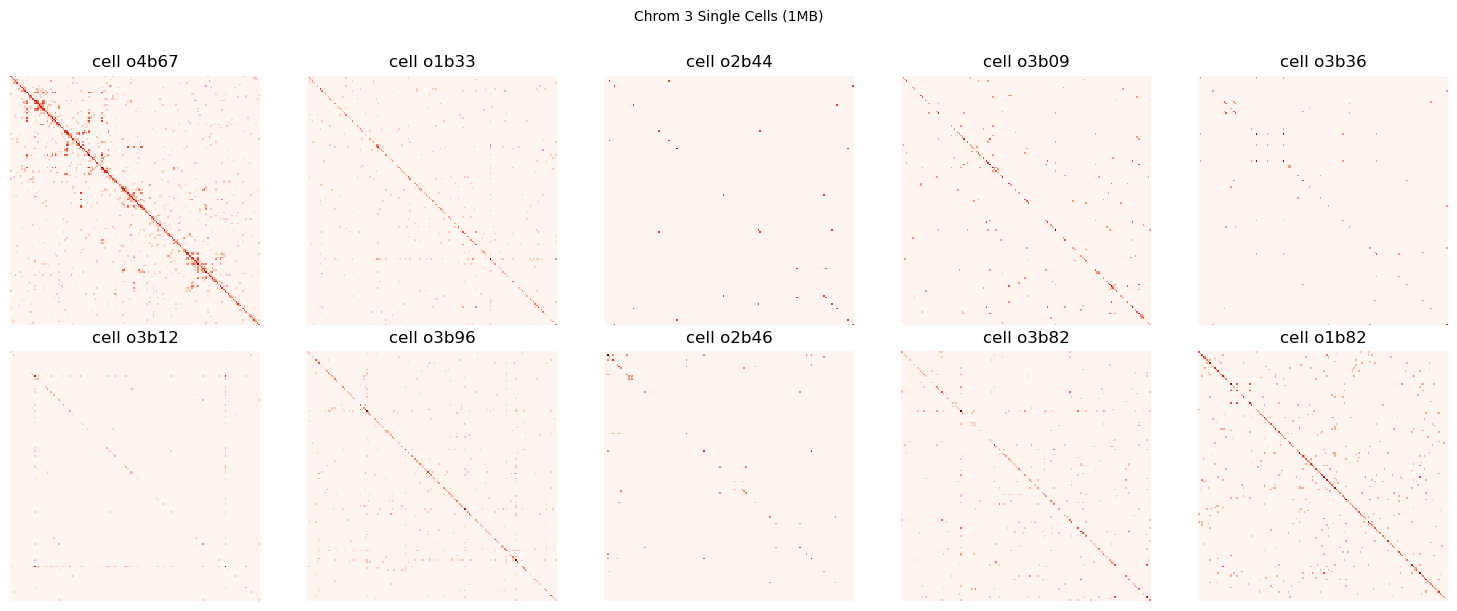

In [25]:
n_cols, n_rows = 5, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*3))
axes = axes.flatten()

for ax, cell_id in zip(axes, cell_ids):
    sns.heatmap(get_clique_matrix(cell_id), cmap=CMAP, square=True, cbar=False, ax=ax, rasterized=True)
    ax.set(xticks=[], yticks=[], title=f"cell {cell_id}", xlabel="", ylabel="")

for ax in axes[N_CELLS:]:
    ax.set_visible(False)

fig.suptitle(f"Chrom 3 Single Cells (1MB)", y=1.01, fontsize=10)
plt.tight_layout()
plt.show()

In [26]:
# ── Find which CN rows correspond to chr7 core positions ─────────────────────
# CN rows in H_core are in the same order as CN dataframe
cn_on_chrom = CN["bin_name"].isin(locus_index[core_positions])
cn_chrom_idx = np.where(cn_on_chrom.values)[0]   # row indices into H_core

# Subset H_core to chr7 CN nodes only, then clique-expand
H_core_chrom = H_core[cn_chrom_idx, :]            # (4 × n_core_edges)
A_core_chrom = H_core_chrom @ H_core_chrom.T      # (4 × 4)
A_core_dense = np.asarray(A_core_chrom.todense())

# Place into full locus grid
n = len(locus_index)
core_overlay = np.zeros((n, n))
core_overlay[np.ix_(core_positions, core_positions)] = A_core_dense
core_overlay = np.ma.masked_where(core_overlay == 0, core_overlay)

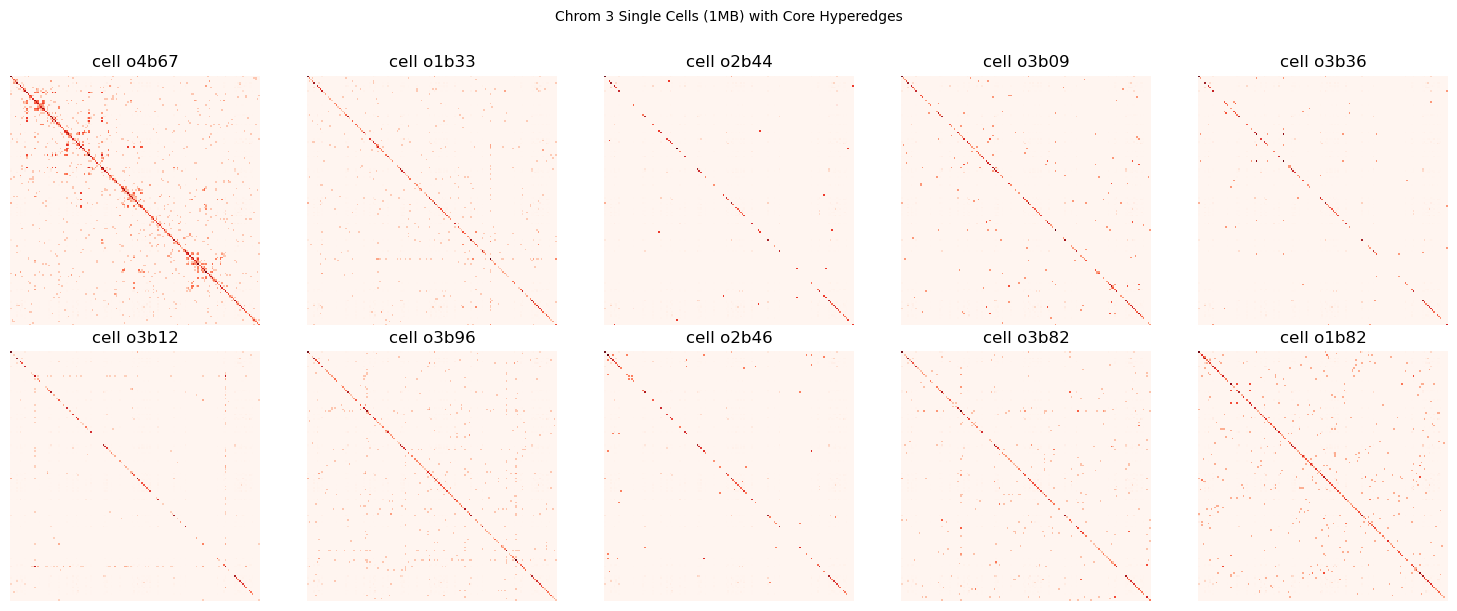

In [28]:
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*3))
axes = axes.flatten()

for ax, cell_id in zip(axes, cell_ids):
    A = get_clique_matrix(cell_id)

    sns.heatmap(A, cmap=CMAP, square=True, cbar=False, ax=ax, rasterized=True)
    ax.set(xticks=[], yticks=[], title=f"cell {cell_id}", xlabel="", ylabel="")

    ax.pcolormesh(core_overlay, cmap="Reds", vmin=0, alpha=0.9, zorder=3, rasterized=True)

for ax in axes[N_CELLS:]:
    ax.set_visible(False)

fig.suptitle(f"Chrom 3 Single Cells (1MB) with Core Hyperedges", y=1.01, fontsize=10)
plt.tight_layout()
plt.show()